Prêt ! Modèle KNN configuré avec 58 dimensions géométriques.

================ RÉSULTATS ISOLÉS (KNN) ================
Précision globale (Accuracy) : 59.56%

                    precision    recall  f1-score   support

Blessé hospitalisé       0.42      0.37      0.40      2643
      Blessé léger       0.67      0.78      0.72      4864
               Tué       0.18      0.02      0.04       580

          accuracy                           0.60      8087
         macro avg       0.43      0.39      0.39      8087
      weighted avg       0.56      0.60      0.57      8087


================ VALIDATION CROISÉE (KNN) ================
Scores pour chaque pli : [0.60973725 0.6137558  0.61391036 0.61230484 0.61957026]
Exactitude moyenne : 61.39%
Stabilité (écart-type) : 0.0032



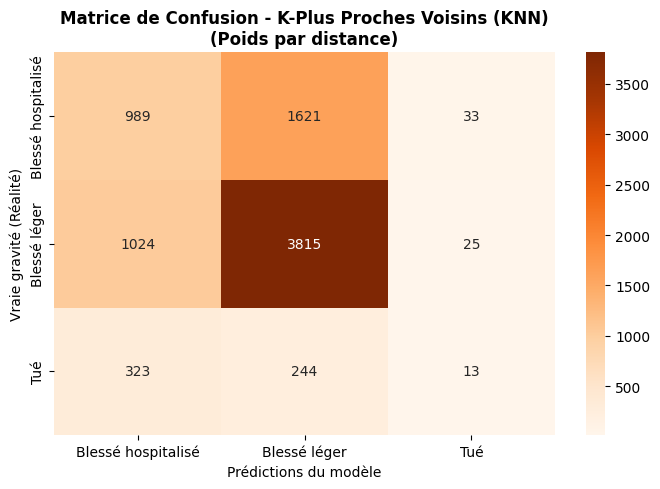

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

base_path = Path.cwd().parent
data_path = base_path / 'data' / 'accidents_2024_clean_base.csv'
df = pd.read_csv(data_path, sep=';', encoding='utf-8')

X_raw = df.drop(columns=['Num_Acc', 'Département', 'Gravité (label)'])
y = df['Gravité (label)']

# OHE : le KNN calcule des distances, il ne peut pas traiter les catégories brutes
X_encoded = pd.get_dummies(X_raw, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# normalisation obligatoire : le KNN mesure des distances, les grandes échelles écraseraient les petites
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Prêt ! Modèle KNN configuré avec {X_train_scaled.shape[1]} dimensions géométriques.")

# weights='distance' : atténue l'effet des classes majoritaires sur les voisins distants
# n_neighbors=80 : k petit amplifie le bruit sur 100+ dimensions — valeur tunée sur ce dataset
model_knn = KNeighborsClassifier(n_neighbors=80, weights='distance')
model_knn.fit(X_train_scaled, y_train)

y_pred = model_knn.predict(X_test_scaled)

print("\n================ RÉSULTATS ISOLÉS (KNN) ================")
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred))

# StratifiedKFold : garantit que les Tués (7%) sont représentés dans chaque fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_knn, X_train_scaled, y_train, cv=cv_strategy, scoring='accuracy')

print("\n================ VALIDATION CROISÉE (KNN) ================")
print(f"Scores pour chaque pli : {cv_scores}")
print(f"Exactitude moyenne : {cv_scores.mean():.2%}")
print(f"Stabilité (écart-type) : {cv_scores.std():.4f}\n")

cm = confusion_matrix(y_test, y_pred)
labels_ordonnes = sorted(y_test.unique())

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_ordonnes, 
            yticklabels=labels_ordonnes)

plt.title('Matrice de Confusion - K-Plus Proches Voisins (KNN)\n(Poids par distance)', fontsize=12, fontweight='bold')
plt.xlabel('Prédictions du modèle')
plt.ylabel('Vraie gravité (Réalité)')
plt.tight_layout()
plt.show()